## Lab 5 BFS & DFS

In [1]:
from collections import deque

def bfs(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    queue = deque([start])
    visited = set()
    visited.add(start)
    parent = {start: None}
    
    while queue:
        current = queue.popleft()
        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], len(visited)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Up, Down, Left, Right
            nr, nc = current[0] + dr, current[1] + dc
            if 0 <= nr < rows and 0 <= nc < cols and maze[nr][nc] == 1 and (nr, nc) not in visited:
                queue.append((nr, nc))
                visited.add((nr, nc))
                parent[(nr, nc)] = current
                
    return None, len(visited)  # No path found

def dfs(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    stack = [start]
    visited = set()
    visited.add(start)
    parent = {start: None}
    
    while stack:
        current = stack.pop()
        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], len(visited)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = current[0] + dr, current[1] + dc
            if 0 <= nr < rows and 0 <= nc < cols and maze[nr][nc] == 1 and (nr, nc) not in visited:
                stack.append((nr, nc))
                visited.add((nr, nc))
                parent[(nr, nc)] = current
                
    return None, len(visited)  # No path found

# Example Maze (0 - Wall, 1 - Path)
maze = [
    [1, 0, 1, 1, 1],
    [1, 1, 1, 0, 1],
    [0, 1, 0, 1, 1],
    [1, 1, 1, 1, 0],
    [0, 0, 0, 1, 1]
]

start = (0, 0)  # Starting point
goal = (4, 4)   # Goal point

# BFS Solution
bfs_path, bfs_nodes = bfs(maze, start, goal)
print("BFS Path:", bfs_path)
print("Nodes Explored in BFS:", bfs_nodes)

# DFS Solution
dfs_path, dfs_nodes = dfs(maze, start, goal)
print("DFS Path:", dfs_path)
print("Nodes Explored in DFS:", dfs_nodes)


BFS Path: [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3), (4, 4)]
Nodes Explored in BFS: 17
DFS Path: [(0, 0), (1, 0), (1, 1), (1, 2), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (2, 3), (3, 3), (4, 3), (4, 4)]
Nodes Explored in DFS: 17


In [3]:
import numpy as np

def confusion_matrix(maze, bfs_visited, dfs_visited):
    rows, cols = len(maze), len(maze[0])
    cm = np.zeros((2, 2), dtype=int)  # Initialize a 2x2 confusion matrix

    for r in range(rows):
        for c in range(cols):
            if maze[r][c] == 1:  # Only consider walkable cells
                if (r, c) in bfs_visited and (r, c) in dfs_visited:
                    cm[0][0] += 1  # True Positive (visited by both BFS and DFS)
                elif (r, c) in bfs_visited:
                    cm[0][1] += 1  # False Negative (visited by BFS but not DFS)
                elif (r, c) in dfs_visited:
                    cm[1][0] += 1  # False Positive (visited by DFS but not BFS)
                else:
                    cm[1][1] += 1  # True Negative (not visited by either)

    return cm

# Example usage:
bfs_visited = {(0, 0), (1, 0), (1, 1), (1, 2), (2, 1), (3, 1), (4, 3), (4, 4)}
dfs_visited = {(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (4, 3), (4, 4)}

cm = confusion_matrix(maze, bfs_visited, dfs_visited)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[7 1]
 [1 8]]


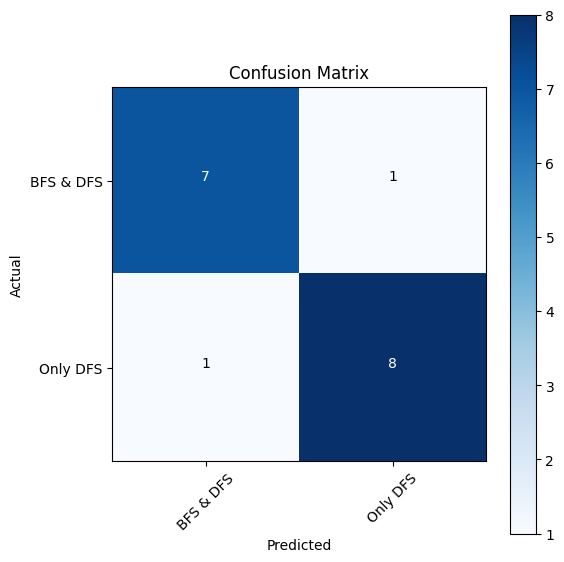

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix(maze, bfs_visited, dfs_visited):
    rows, cols = len(maze), len(maze[0])
    cm = np.zeros((2, 2), dtype=int)  # Initialize a 2x2 confusion matrix

    for r in range(rows):
        for c in range(cols):
            if maze[r][c] == 1:  # Only consider walkable cells
                if (r, c) in bfs_visited and (r, c) in dfs_visited:
                    cm[0][0] += 1  # True Positive (visited by both BFS and DFS)
                elif (r, c) in bfs_visited:
                    cm[0][1] += 1  # False Negative (visited by BFS but not DFS)
                elif (r, c) in dfs_visited:
                    cm[1][0] += 1  # False Positive (visited by DFS but not BFS)
                else:
                    cm[1][1] += 1  # True Negative (not visited by either)

    return cm

def plot_confusion_matrix(cm, labels=["BFS & DFS", "Only DFS"], title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)

    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, format(cm[i][j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i][j] > cm.max() / 2 else "black")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Example usage
bfs_visited = {(0, 0), (1, 0), (1, 1), (1, 2), (2, 1), (3, 1), (4, 3), (4, 4)}
dfs_visited = {(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (4, 3), (4, 4)}

cm = confusion_matrix(maze, bfs_visited, dfs_visited)
plot_confusion_matrix(cm)


In [5]:
from collections import deque

def bfs(graph, start, goal):
    # Queue to manage BFS traversal
    queue = deque([start])
    visited = set()  # To track explored nodes
    parent = {start: None}  # To reconstruct the path

    while queue:
        current = queue.popleft()
        visited.add(current)

        if current == goal:  # If goal is reached
            # Backtrack using the parent dictionary to reconstruct the path
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], len(visited)

        # Explore neighbors
        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in queue:
                queue.append(neighbor)
                parent[neighbor] = current

    return None, len(visited)  # If no path exists

# Graph representation of the maze (based on the PDF)
graph = {
    'A': ['B'],
    'B': ['A', 'C'],
    'C': ['B', 'D', 'G'],
    'D': ['C', 'E'],
    'E': ['D', 'F'],
    'F': ['E'],
    'G': ['C', 'H'],
    'H': ['G', 'K', 'I'],
    'I': ['H', 'J'],
    'J': ['I'],
    'K': ['H', 'L'],
    'L': ['K', 'M'],
    'M': ['L', 'N'],
    'N': ['M']
}

# Run BFS
solution_path, nodes_explored = bfs(graph, 'A', 'N')
print("BFS Solution Path:", solution_path)
print("Nodes Explored by BFS:", nodes_explored)


BFS Solution Path: ['A', 'B', 'C', 'G', 'H', 'K', 'L', 'M', 'N']
Nodes Explored by BFS: 14


In [6]:
def dfs(graph, start, goal):
    stack = [start]
    visited = set()  # To track explored nodes
    parent = {start: None}  # To reconstruct the path

    while stack:
        current = stack.pop()
        visited.add(current)

        if current == goal:  # If goal is reached
            # Backtrack using the parent dictionary to reconstruct the path
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], len(visited)

        # Explore neighbors
        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in stack:
                stack.append(neighbor)
                parent[neighbor] = current

    return None, len(visited)  # If no path exists

# Run DFS
solution_path_dfs, nodes_explored_dfs = dfs(graph, 'A', 'N')
print("DFS Solution Path:", solution_path_dfs)
print("Nodes Explored by DFS:", nodes_explored_dfs)


DFS Solution Path: ['A', 'B', 'C', 'G', 'H', 'K', 'L', 'M', 'N']
Nodes Explored by DFS: 11


In [17]:
from collections import deque

# Breadth-First Search (BFS) to find the shortest path
def bfs(graph, start, goal):
    queue = deque([start])
    visited = set()
    parent = {start: None}
    
    while queue:
        current = queue.popleft()
        visited.add(current)
        
        if current == goal:
            # Reconstruct path from start to goal
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], len(visited)  # Shortest path, number of nodes explored
        
        # Explore neighbors
        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in queue:
                queue.append(neighbor)
                parent[neighbor] = current
                
    return None, len(visited)  # No path found

# Depth-First Search (DFS) to explore all possible paths and find one valid path
def dfs(graph, start, goal):
    stack = [start]
    visited = set()
    parent = {start: None}
    
    while stack:
        current = stack.pop()
        if current not in visited:
            visited.add(current)
            
            if current == goal:
                # Reconstruct path from start to goal
                path = []
                while current:
                    path.append(current)
                    current = parent[current]
                return path[::-1], len(visited)  # Valid path, number of nodes explored
            
            # Explore neighbors
            for neighbor in graph[current]:
                if neighbor not in visited:
                    stack.append(neighbor)
                    parent[neighbor] = current
                    
    return None, len(visited)  # No path found

# Graph representation of the maze (based on the PDF)
graph = {
    'A': ['B'],
    'B': ['A', 'C'],
    'C': ['B', 'D', 'G'],
    'D': ['C', 'E'],
    'E': ['D', 'F'],
    'F': ['E'],
    'G': ['C', 'H'],
    'H': ['G', 'K', 'I'],
    'I': ['H', 'J'],
    'J': ['I'],
    'K': ['H', 'L'],
    'L': ['K', 'M'],
    'M': ['L', 'N'],
    'N': ['M']
}

# Run BFS
bfs_path, bfs_explored = bfs(graph, 'A', 'N')
print("BFS:")
print("Shortest Path:", bfs_path)
print("Nodes Explored:", bfs_explored)

# Run DFS
dfs_path, dfs_explored = dfs(graph, 'A', 'N')
print("\nDFS:")
print("Valid Path:", dfs_path)
print("Nodes Explored:", dfs_explored)

# Comparison
print("\nComparison:")
print(f"BFS explored {bfs_explored} nodes.")
print(f"DFS explored {dfs_explored} nodes.")


BFS:
Shortest Path: ['A', 'B', 'C', 'G', 'H', 'K', 'L', 'M', 'N']
Nodes Explored: 14

DFS:
Valid Path: ['A', 'B', 'C', 'G', 'H', 'K', 'L', 'M', 'N']
Nodes Explored: 11

Comparison:
BFS explored 14 nodes.
DFS explored 11 nodes.
